# <span style="color:black; font-weight:bold;">Cross platform alignment Coronal brain Tutorial</span>
+ <span style="color:black; font-weight:bold;">Creator</span>: Bingjie Dai (17516970902@163.com)
+ <span style="color:black; font-weight:bold;">Date of Creation</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Date of Last Modification</span>: 6.23.2026
+ <span style="color:black; font-weight:bold;">Download</span>: Cross-platform coronal brain data used in the tutorial are available at [AMBC_STARmapPLUS_processed_round1.h5ad](https://drive.google.com/file/d/1-l2_4Js8h8WQXPHp1YukJatZQl7O9ONG/view?usp=sharing) , [AMBC_CosMx_processed_round1.h5ad](https://drive.google.com/file/d/12TY_5-YI6QioR2GjUHE7FteIi50jRrJa/view?usp=sharing) , [AMBC_MERFISH_processed_round1.h5ad](https://drive.google.com/file/d/1OvEfcBHe-03rGIQfNtXZ5RVhQKUaQ7HH/view?usp=sharing) , [AMBC_Slideseq_processed_round1.h5ad](https://drive.google.com/file/d/1QC5vbGu_4NzhtEiiCute9_cGCWleVCFB/view?usp=sharing),  
+ <span style="color:black; font-weight:bold;"></span>:[AMBC_Stereoseq_processed_round1.h5ad](https://drive.google.com/file/d/1RyIJm3uYn3QsqntKFh0IHfsPtPZ_OP2g/view?usp=sharing), [AMBC_Xenium_processed_round1.h5ad](https://drive.google.com/file/d/1q9c0pL1SrOl7ZidjP8KxjHtN5hlD7bkB/view?usp=sharing) , [AMBC_Xenium5k_processed_round1.h5ad](https://drive.google.com/file/d/1SxhZSzbSRaKf2wgvz6ny2mP_m_TDhdk0/view?usp=sharing) , [AMBC_VisiumHD_processed_round1.h5ad](https://drive.google.com/file/d/11SWX9BEnYspXCcSKNXY7UWBzxWfnCRXy/view?usp=sharing) and [AMBC_ST_processed_round1.h5ad](https://drive.google.com/file/d/12gqjm240GY_x-rq56Qy5dKos3KOq8BQq/view?usp=sharing). 


<span style="color:black; font-weight:bold;">The dataset have:</span>   
+ <span style="color:black; font-weight:bold;">STARmapPLUS</span>: 43,341 cells and 1022 genes   
+ <span style="color:black; font-weight:bold;">CosMx</span>: 48,113 cells and 950 genes   
+ <span style="color:black; font-weight:bold;">MERFISH</span>: 43,858 cells and 483 genes  
+ <span style="color:black; font-weight:bold;">Slideseq</span>: 139,944 spots and 26,957 genes  
+ <span style="color:black; font-weight:bold;">Stereoseq</span>: 56,048 bins and 24,012 genes     
+ <span style="color:black; font-weight:bold;">Xenium</span>: 83,381 cells and 248 genes  
+ <span style="color:black; font-weight:bold;">Xenium5k</span>: 62,984 cells and 5006 genes  
+ <span style="color:black; font-weight:bold;">VisiumHD</span>: 452,701 spots and 17,797 genes  
+ <span style="color:black; font-weight:bold;">ST</span>: 620 spots and 16,240 genes

In [1]:
from MAPS.align import Multi_slices_rigid_alignment
from MAPS.utils import set_seed,create_new_color_dict
import scanpy as sc
import pandas as pd
import torch
import numpy as np
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [3]:
set_seed(2026)

## <span style="color:black; font-weight:bold;">Loading Cross-platform mouse brain data</span>
#### To ensure the accuracy of the scaling factor, we recommend using the slice with a larger initial coordinate range as the target_adata for learning the scaling factor.

In [4]:
adata1=sc.read_h5ad('/home/dbj/LPcross/Data/AMBCS_processed/round_1/AMBC_STARmapPLUS_processed_round1.h5ad')
adata1.obs['batch']='STARmapPLUS'

adata2=sc.read_h5ad('/home/dbj/LPcross/Data/AMBCS_processed/round_1/AMBC_CosMx_processed_round1.h5ad')
adata2.obs['batch']='CosMx'

adata3=sc.read_h5ad('/home/dbj/LPcross/Data/AMBCS_processed/round_1/AMBC_MERFISH_processed_round1.h5ad')
adata3.obs['batch']='MERFISH'

adata4=sc.read_h5ad('/home/dbj/LPcross/Data/AMBCS_processed/round_1/AMBC_Slideseq_processed_round1.h5ad')
adata4.obs['batch']='Slideseq'

adata5=sc.read_h5ad('/home/dbj/LPcross/Data/AMBCS_processed/round_1/AMBC_Stereoseq_processed_round1.h5ad')
adata5.obs['batch']='Stereoseq'

adata6=sc.read_h5ad('/home/dbj/LPcross/Data/AMBCS_processed/round_1/AMBC_Xenium_processed_round1.h5ad')
adata6.obs['batch']='Xenium'

adata7=sc.read_h5ad('/home/dbj/LPcross/Data/AMBCS_processed/round_1/AMBC_Xenium5k_processed_round1.h5ad')
adata7.obs['batch']='Xenium5k'

adata8=sc.read_h5ad('/home/dbj/LPcross/Data/AMBCS_processed/round_1/AMBC_VisiumHD_processed_round1.h5ad')
adata8.obs['batch']='VisiumHD'

adata9=sc.read_h5ad('/home/dbj/LPcross/Data/AMBCS_processed/round_1/AMBC_ST_processed_round1.h5ad')
adata9.obs['batch']='ST'

## <span style="color:black; font-weight:bold;">Spatial mapping of the cross-platform mouse brain before alignment</span>

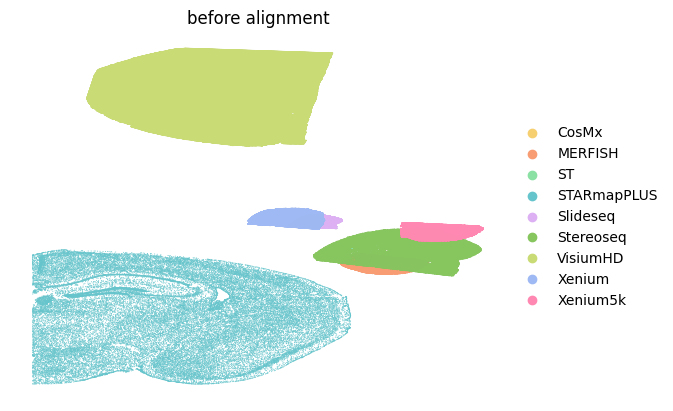

In [5]:
adata_list=[adata1,adata2,adata3,adata4,adata5,adata6,adata7,adata8,adata9]
adata=sc.concat(adata_list,join='inner')

color_dict=create_new_color_dict(adata,cat_key='batch')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='before alignment',size=2,frameon=False,palette=color_dict)

## <span style="color:black; font-weight:bold;">Reference align using MAPS for multi-slices</span> 
### <span style="color:black; font-weight:bold;">Training parameters</span> 
epochs: Training ephchs  
device: Training device  
sample_size: The number of samples used for alignment  
enable_scale: Whether to learn the scaling factor?  
mode: 'reference' The slices are aligned to the reference target  
ref_idx: Reference target, the other slices are aligned to the target slice

### <span style="color:black; font-weight:bold;">Output</span>   
reference_list: A list of slices after reference align

In [6]:
%%time
reference_adata_list = Multi_slices_rigid_alignment(adata_list, mode='reference', ref_idx=0,epochs=1000, sample_size=10000, enable_scale=True, device=device)


--- Slice 1 is the reference, skipping ---

--- Aligning Slice 2 to Reference (Slice 1) ---
Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████| 1000/1000 [00:05<00:00, 176.92it/s, Loss=230.49, Scale=5141.734, Rot=119.51°, Trans=(-14666.0, -16656.1)]


Peak GPU memory usage: 1.244 GB
Scale factor: 5141.734, Rotation angle: 118.58°, Translation (x, y): (-14665.45, -16650.01)

--- Aligning Slice 3 to Reference (Slice 1) ---
Scanning angles to find best starting angle...


Global Align: 100%|███████████████████████████| 1000/1000 [00:05<00:00, 194.47it/s, Loss=146.40, Scale=5.290, Rot=108.82°, Trans=(-17419.1, -13058.3)]


Peak GPU memory usage: 1.244 GB
Scale factor: 5.289, Rotation angle: 109.63°, Translation (x, y): (-17425.89, -13057.84)

--- Aligning Slice 4 to Reference (Slice 1) ---
Scanning angles to find best starting angle...


...

Peak GPU memory usage: 1.244 GB
Scale factor: 5.306, Rotation angle: 100.45°, Translation (x, y): (-21819.26, -21137.16)

--- Aligning Slice 8 to Reference (Slice 1) ---
Scanning angles to find best starting angle...


Global Align: 100%|███████████████████████████| 1000/1000 [00:05<00:00, 191.92it/s, Loss=143.76, Scale=1.324, Rot=-173.20°, Trans=(-3446.8, -56851.5)]


Peak GPU memory usage: 1.256 GB
Scale factor: 1.323, Rotation angle: -173.19°, Translation (x, y): (-3446.16, -56854.16)

--- Aligning Slice 9 to Reference (Slice 1) ---
Scanning angles to find best starting angle...


Global Align: 100%|████████████████████████| 1000/1000 [00:01<00:00, 523.51it/s, Loss=146.18, Scale=4836.353, Rot=169.02°, Trans=(-14374.8, -17216.7)]


Peak GPU memory usage: 0.092 GB
Scale factor: 4836.353, Rotation angle: 169.61°, Translation (x, y): (-14373.91, -17213.78)

--- All slices have been aligned! ---
CPU times: user 39.5 s, sys: 30.1 s, total: 1min 9s
Wall time: 1min 15s


## <span style="color:black; font-weight:bold;">Spatial mapping of the reference alignment result for cross-platform mouse brain</span>

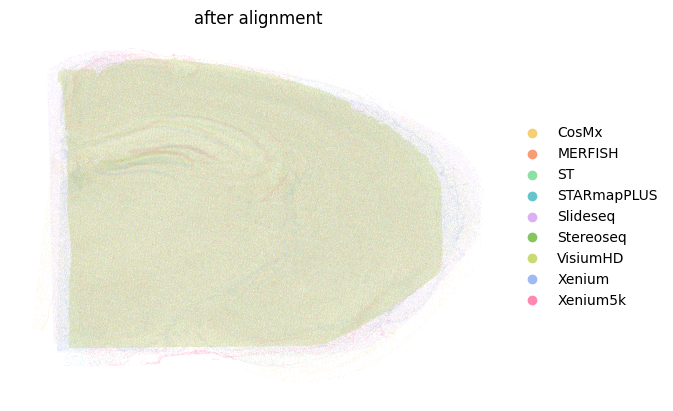

In [7]:
adata=sc.concat(reference_adata_list,join='inner')
sc.pl.embedding(adata=adata, basis='spatial',color='batch',title='after alignment',size=0.2,frameon=False,palette=color_dict)